In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library


<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/internationaal/thinktank/fotos-en-logos/ku-leuven-logo.png/image_preview" width = auto, heigh = 200px align=left>
</div>


KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">**TODO**: Add your names below.</span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red">name1, name2, ...</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [3]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    './kaggle/input/kul-computer-vision-ga-1-2025/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    './kaggle/input/kul-computer-vision-ga-1-2025/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('./kaggle/input/kul-computer-vision-ga-1-2025/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('./kaggle/input/kul-computer-vision-ga-1-2025/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [4]:
# The training set contains an identifier, name, image information and class label
train.head(1)

,name,class,img
id,,,
0,Mila_Kunis,2,"[[[50, 31, 25], [49, 30, 24], [49, 30, 24], [4..."


In [5]:
# The test set only contains an identifier and corresponding image information.

test.head(1)

,img
id,
0,"[[[209, 210, 205], [208, 209, 204], [208, 209,..."


In [6]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

,img,class
name,,
Jesse_Eisenberg,30,1
Michael_Cera,10,0
Mila_Kunis,30,2
Sarah_Hyland,10,0


Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [12]:
class HAARPreprocessor():
    """Preprocessing pipeline built around HAAR feature based cascade classifiers. """
    
    def __init__(self, path, face_size):
        self.face_size = face_size
        file_path = os.path.join(path, "haarcascade_frontalface_default.xml")
        if not os.path.exists(file_path): 
            if not os.path.exists(path):
                os.mkdir(path)
            self.download_model(file_path)
        
        self.classifier = cv2.CascadeClassifier(file_path)
  
    def download_model(self, path):
        url = "https://raw.githubusercontent.com/opencv/opencv/master/data/"\
            "haarcascades/haarcascade_frontalface_default.xml"
        
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())
            
    def detect_faces(self, img):
        """Detect all faces in an image."""
        
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return self.classifier.detectMultiScale(
            img_gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
    def extract_faces(self, img):
        """Returns all faces (cropped) in an image."""
        
        faces = self.detect_faces(img)

        return [img[y:y+h, x:x+w] for (x, y, w, h) in faces]
    
    def preprocess(self, data_row):
        faces = self.extract_faces(data_row['img'])
        
        # if no faces were found, return a black image
        if len(faces) == 0:
            return np.zeros(self.face_size + (3,), dtype=np.uint8)
        
        # only return the first face
        return cv2.resize(faces[0], self.face_size, interpolation=cv2.INTER_AREA).astype(np.uint8)
            
    def __call__(self, data):
        return np.stack([self.preprocess(row) for _, row in data.iterrows()])

**Visualise**

Let's plot a few examples.

In [13]:
# parameter to play with 
FACE_SIZE = (100, 100)

def plot_image_sequence(data, n, imgs_per_row=7):
    n_rows = 1 + int(n/(imgs_per_row+1))
    n_cols = min(imgs_per_row, n)

    f,ax = plt.subplots(n_rows,n_cols, figsize=(10*n_cols,10*n_rows))
    for i in range(n):
        if n == 1:
            ax.imshow(data[i])
        elif n_rows > 1:
            ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i])
        else:
            ax[int(i%n)].imshow(data[i])
    plt.show()

    
#preprocessed data 
preprocessor = HAARPreprocessor(path = './kaggle/tmp', face_size=FACE_SIZE)

train_X, train_y = preprocessor(train), train['class'].values
test_X = preprocessor(test)



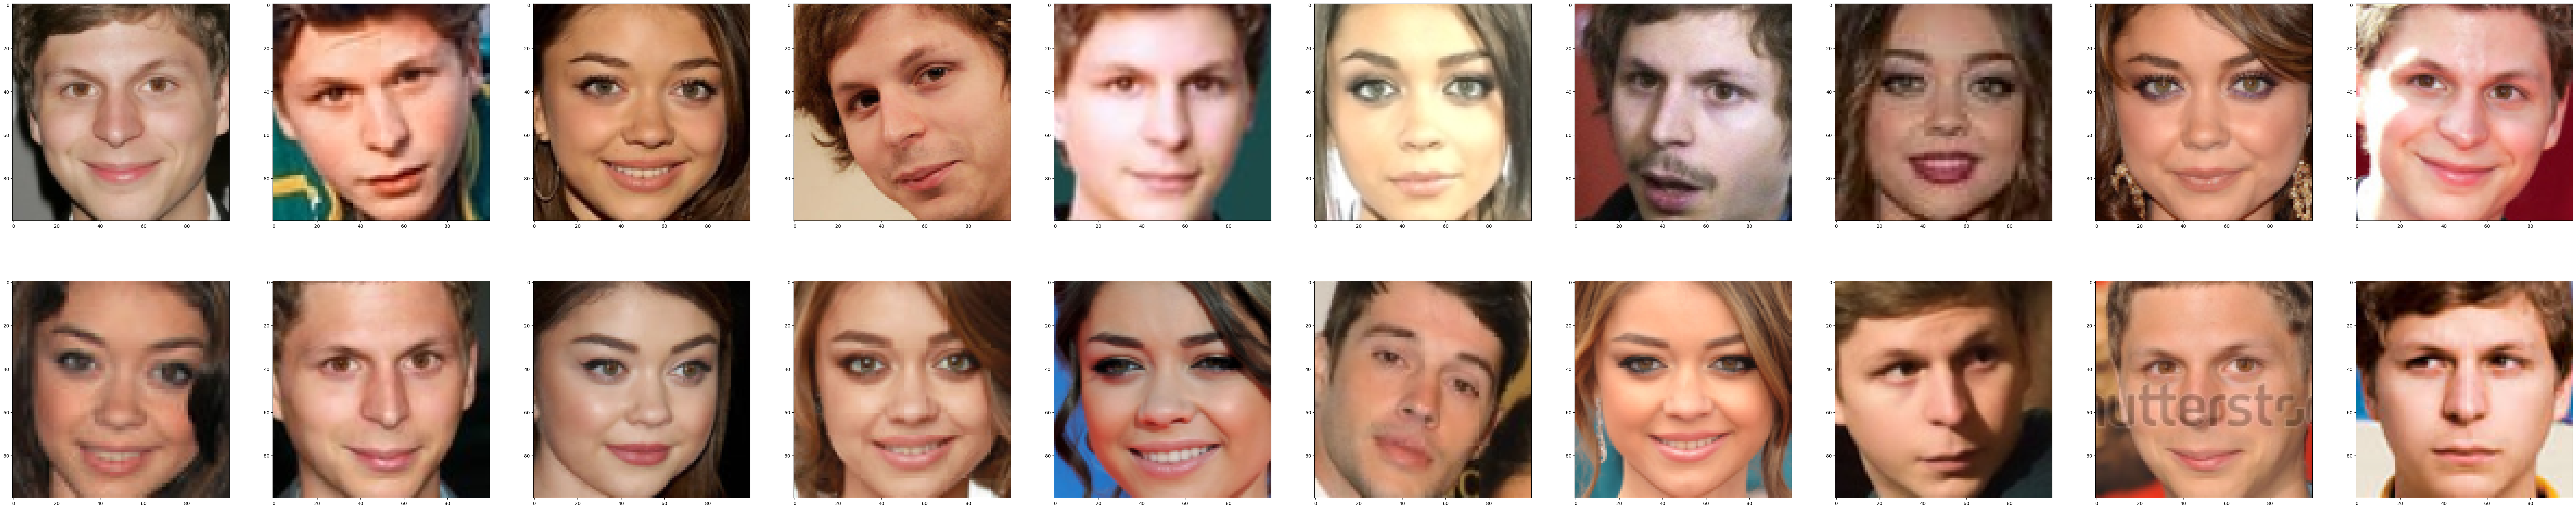

In [14]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

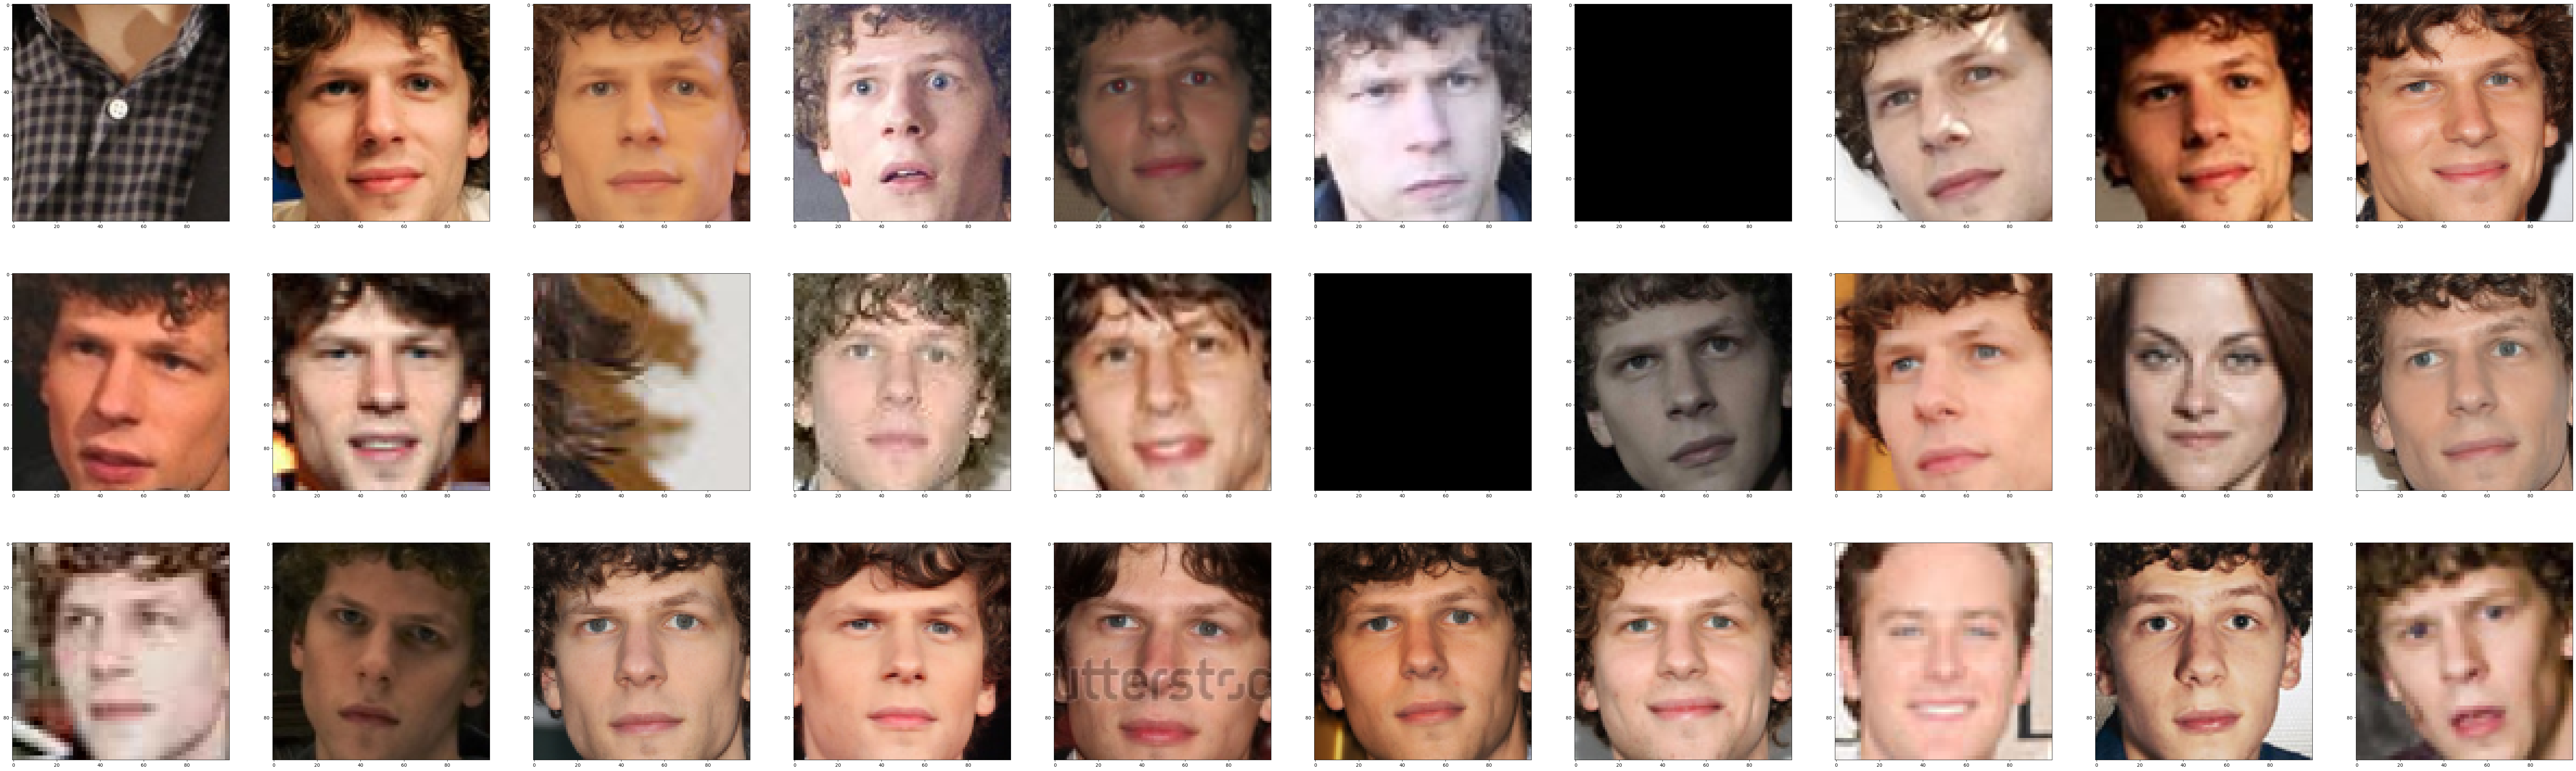

In [16]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

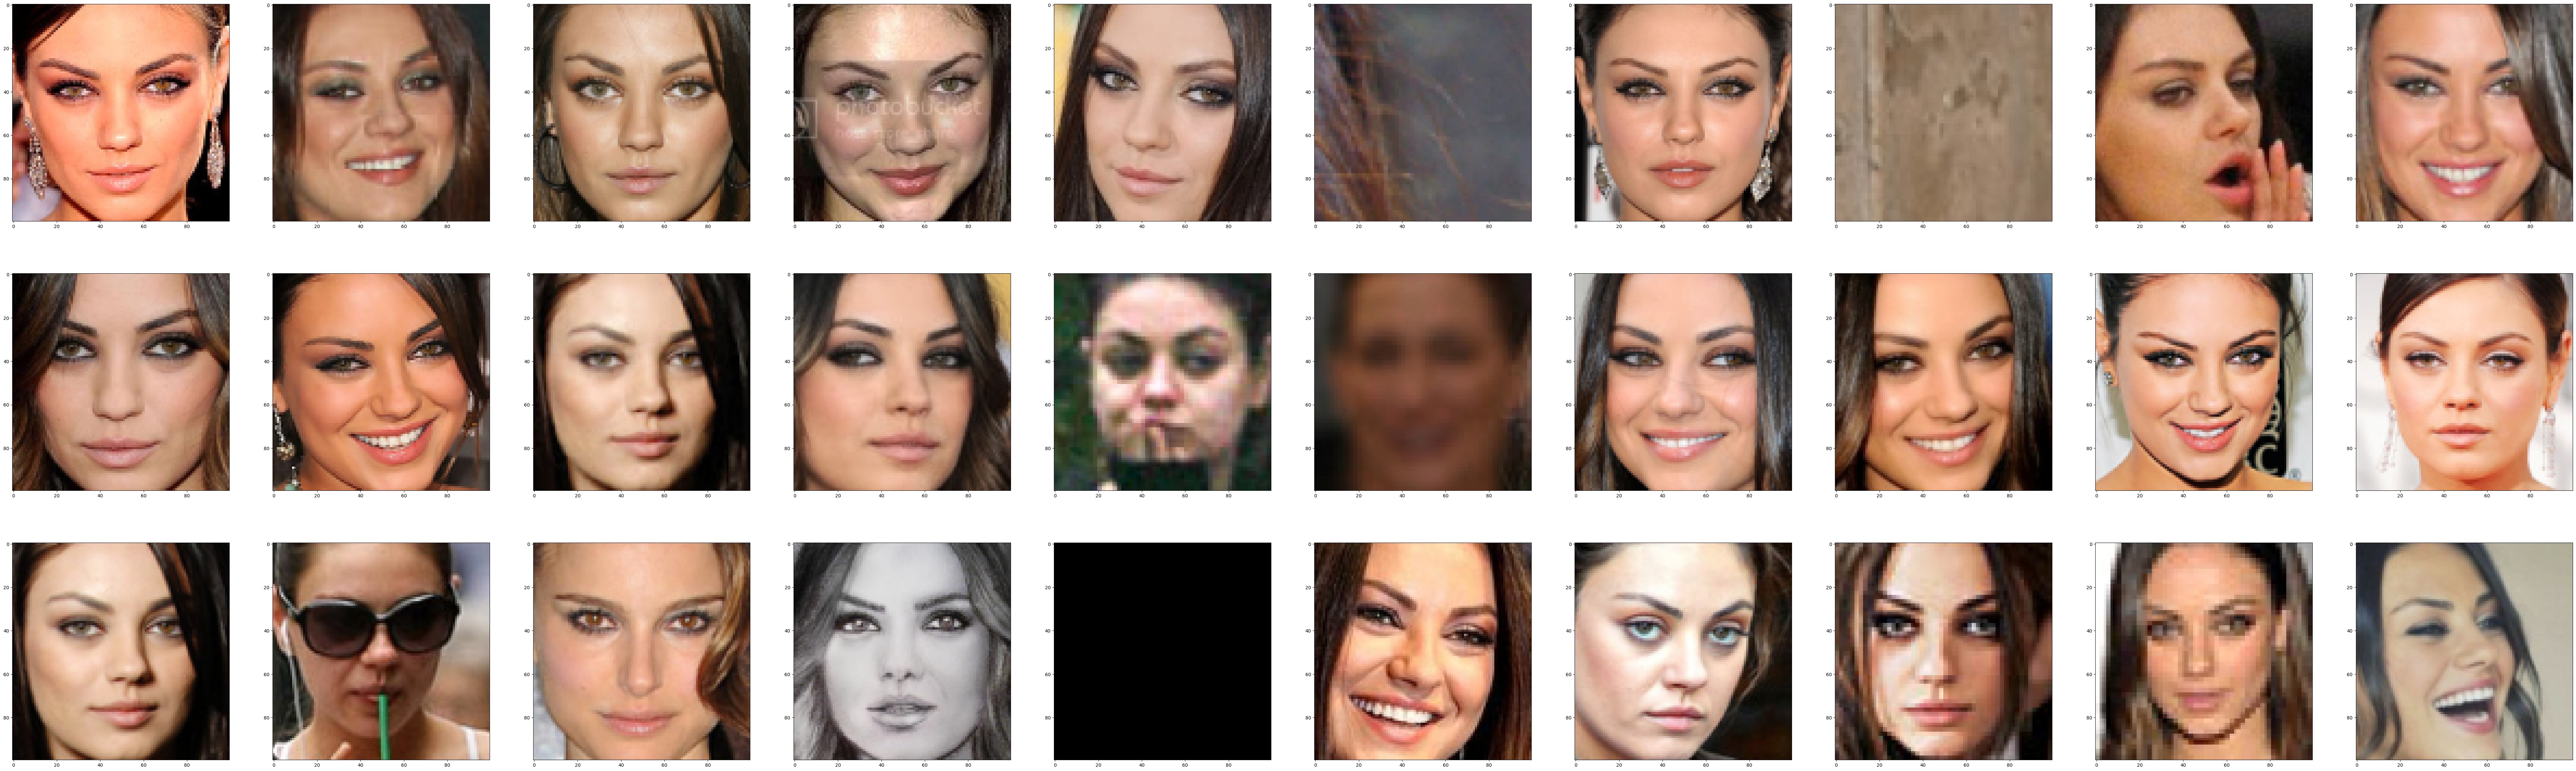

In [17]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [64]:
# save preprocessed data
prep_path = './kaggle/working/prepped_data/'
if not os.path.exists(prep_path):
    os.mkdir(prep_path)
    
np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

# load preprocessed data
prep_path = './kaggle/working/prepped_data/'
if not os.path.exists(prep_path):
    os.mkdir(prep_path)
train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations
## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [69]:
# ==========================================
# FEATURE EXTRACTOR CLASSES
# ==========================================
import cv2
import numpy as np
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore') # Hides annoying KMeans convergence warnings

class OptimizedHOG():
    """Extracts HOG features based on provided cell and block parameters."""
    def __init__(self, cell_size=(10, 10), block_size=(20, 20)):
        self.hog = cv2.HOGDescriptor(
            _winSize=(100, 100),
            _blockSize=block_size,
            _blockStride=cell_size, 
            _cellSize=cell_size,
            _nbins=9
        )
        
    def transform(self, images):
        features = []
        for img in images:
            if len(img.shape) == 3:
                gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            else:
                gray = img
            features.append(self.hog.compute(gray).flatten())
        return np.array(features)

class OptimizedSIFT():
    """Extracts SIFT features, heavily modified to allow custom search sizes."""
    
    # Notice we added sigma and contrast_thresh here!
    def __init__(self, n_clusters=30, max_features=150, sigma=1.6, contrast_thresh=0.04):
        self.sift = cv2.SIFT_create(
            nfeatures=max_features,
            sigma=sigma,                     
            contrastThreshold=contrast_thresh 
        )
        self.n_clusters = n_clusters
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init='auto')
        self.vocab_trained = False
        
    def _get_descriptors(self, images):
        desc_list = []
        for img in images:
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
            _, des = self.sift.detectAndCompute(gray, None)
            desc_list.append(des if des is not None else np.zeros((1, 128), dtype=np.float32))
        return desc_list

    def fit_transform(self, images):
        self.train_desc = self._get_descriptors(images)
        all_desc = np.vstack(self.train_desc)
        self.kmeans.fit(all_desc)
        self.vocab_trained = True
        return self.transform(images, precomputed=self.train_desc)

    def transform(self, images, precomputed=None):
        descs = precomputed if precomputed else self._get_descriptors(images)
        features = np.zeros((len(images), self.n_clusters))
        for i, des in enumerate(descs):
            if not np.all(des == 0):
                words = self.kmeans.predict(des.astype(np.float32))
                for word in words:
                    features[i, word] += 1
        return features

print("✅ Feature Extractor Classes Loaded Successfully!")

✅ Feature Extractor Classes Loaded Successfully!


## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform
...

In [70]:
# ==========================================
# HYPERPARAMETER GRID SEARCH FOR HOG & SIFT
# ==========================================
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import time

print("--- Starting Automated Feature Optimization ---")
# Split validation set
X_t, X_v, y_t, y_v = train_test_split(train_X, train_y, test_size=0.2, random_state=42, stratify=train_y)

# ---------------------------------------------------------
# 1. OPTIMIZE HOG
# ---------------------------------------------------------
print("\n🔍 Searching for best HOG configuration...")
hog_grid = [
    {'name': 'Macro',  'cell': (50, 50), 'block': (100, 100)},
    {'name': 'XLarge', 'cell': (25, 25), 'block': (50, 50)},
    {'name': 'Coarse', 'cell': (20, 20), 'block': (40, 40)},
    {'name': 'Medium', 'cell': (10, 10), 'block': (20, 20)},
    {'name': 'Fine',   'cell': (5, 5),   'block': (10, 10)}
]

best_hog_score = 0
best_hog_config = None

for config in hog_grid:
    extractor = OptimizedHOG(cell_size=config['cell'], block_size=config['block'])
    train_feat = extractor.transform(X_t)
    val_feat = extractor.transform(X_v)
    
    clf = LinearSVC(random_state=42, class_weight='balanced', dual=False)
    clf.fit(train_feat, y_t)
    score = f1_score(y_v, clf.predict(val_feat), average='weighted')
    
    print(f"  Tested HOG {config['name']:<6} (Cell: {config['cell']}) -> F1: {score:.4f}")
    if score > best_hog_score:
        best_hog_score = score
        best_hog_config = config

# ---------------------------------------------------------
# 2. OPTIMIZE SIFT (BoVW)
# ---------------------------------------------------------
print("\n🔍 Searching for best SIFT configuration...")
sift_grid = [
    {'clusters': 15, 'sigma': 1.6, 'contrast': 0.04, 'name': 'Standard-Small'},
    {'clusters': 30, 'sigma': 1.6, 'contrast': 0.04, 'name': 'Standard-Med'},
    {'clusters': 15, 'sigma': 3.0, 'contrast': 0.08, 'name': 'Enlarged-Small'},
    {'clusters': 30, 'sigma': 3.0, 'contrast': 0.08, 'name': 'Enlarged-Med'},
]

best_sift_score = 0
best_sift_config = None

for config in sift_grid:
    start_time = time.time()
    extractor = OptimizedSIFT(
        n_clusters=config['clusters'], 
        max_features=150, 
        sigma=config['sigma'], 
        contrast_thresh=config['contrast']
    )
    
    train_feat = extractor.fit_transform(X_t)
    val_feat = extractor.transform(X_v)
    
    clf = LinearSVC(random_state=42, class_weight='balanced', dual=False)
    clf.fit(train_feat, y_t)
    score = f1_score(y_v, clf.predict(val_feat), average='weighted')
    
    print(f"  Tested SIFT {config['name']:<15} -> F1: {score:.4f}")
    if score > best_sift_score:
        best_sift_score = score
        best_sift_config = config

# ---------------------------------------------------------
# 3. RESULTS
# ---------------------------------------------------------
print("\n" + "="*40)
print("🏆 OPTIMIZATION COMPLETE 🏆")
print("="*40)
print(f"Best HOG:  {best_hog_config['name']} | Score: {best_hog_score:.4f}")
print(f"Best SIFT: {best_sift_config['name']} | Score: {best_sift_score:.4f}")

--- Starting Automated Feature Optimization ---

🔍 Searching for best HOG configuration...
  Tested HOG Macro  (Cell: (50, 50)) -> F1: 0.4038
  Tested HOG XLarge (Cell: (25, 25)) -> F1: 0.5584
  Tested HOG Coarse (Cell: (20, 20)) -> F1: 0.5584
  Tested HOG Medium (Cell: (10, 10)) -> F1: 0.6834
  Tested HOG Fine   (Cell: (5, 5)) -> F1: 0.6845

🔍 Searching for best SIFT configuration...
  Tested SIFT Standard-Small  -> F1: 0.3875
  Tested SIFT Standard-Med    -> F1: 0.6120
  Tested SIFT Enlarged-Small  -> F1: 0.5713
  Tested SIFT Enlarged-Med    -> F1: 0.3023

🏆 OPTIMIZATION COMPLETE 🏆
Best HOG:  Fine | Score: 0.6845
Best SIFT: Standard-Med | Score: 0.6120


In [71]:
# ==========================================
# FINAL EXTRACTION & EXPORT
# ==========================================
from sklearn.preprocessing import StandardScaler
import numpy as np

print(f"1. Extracting final HOG features using {best_hog_config['name']} parameters...")
final_hog = OptimizedHOG(
    cell_size=best_hog_config['cell'], 
    block_size=best_hog_config['block']
)
hog_train_full = final_hog.transform(train_X)
hog_test_full = final_hog.transform(test_X)

print(f"2. Extracting final SIFT features using {best_sift_config['name']} parameters...")
final_sift = OptimizedSIFT(
    n_clusters=best_sift_config['clusters'], 
    max_features=150,
    sigma=best_sift_config['sigma'],
    contrast_thresh=best_sift_config['contrast']
)
sift_train_full = final_sift.fit_transform(train_X)
sift_test_full = final_sift.transform(test_X)

print("3. Standardizing features for SVM optimization (Crucial step!)...")
# Standard scaling makes SVM gradient descent extremely fast and accurate
scaler_hog = StandardScaler()
hog_train_scaled = scaler_hog.fit_transform(hog_train_full)
hog_test_scaled = scaler_hog.transform(hog_test_full)

scaler_sift = StandardScaler()
sift_train_scaled = scaler_sift.fit_transform(sift_train_full)
sift_test_scaled = scaler_sift.transform(sift_test_full)

print("4. Saving to 'group16_features.npz'...")
np.savez_compressed(
    'group16_features.npz', 
    hog_train=hog_train_scaled, 
    hog_test=hog_test_scaled, 
    sift_train=sift_train_scaled, 
    sift_test=sift_test_scaled,
    train_y=train_y
)

print("\n✅ DONE! All optimized features extracted, scaled, and saved.")

1. Extracting final HOG features using Fine parameters...
2. Extracting final SIFT features using Standard-Med parameters...
3. Standardizing features for SVM optimization (Crucial step!)...
4. Saving to 'group16_features.npz'...

✅ DONE! All optimized features extracted, scaled, and saved.


Visualize HOG/SIFT Features using t-SNE

Running t-SNE on optimized HOG features...
Running t-SNE on optimized SIFT features...


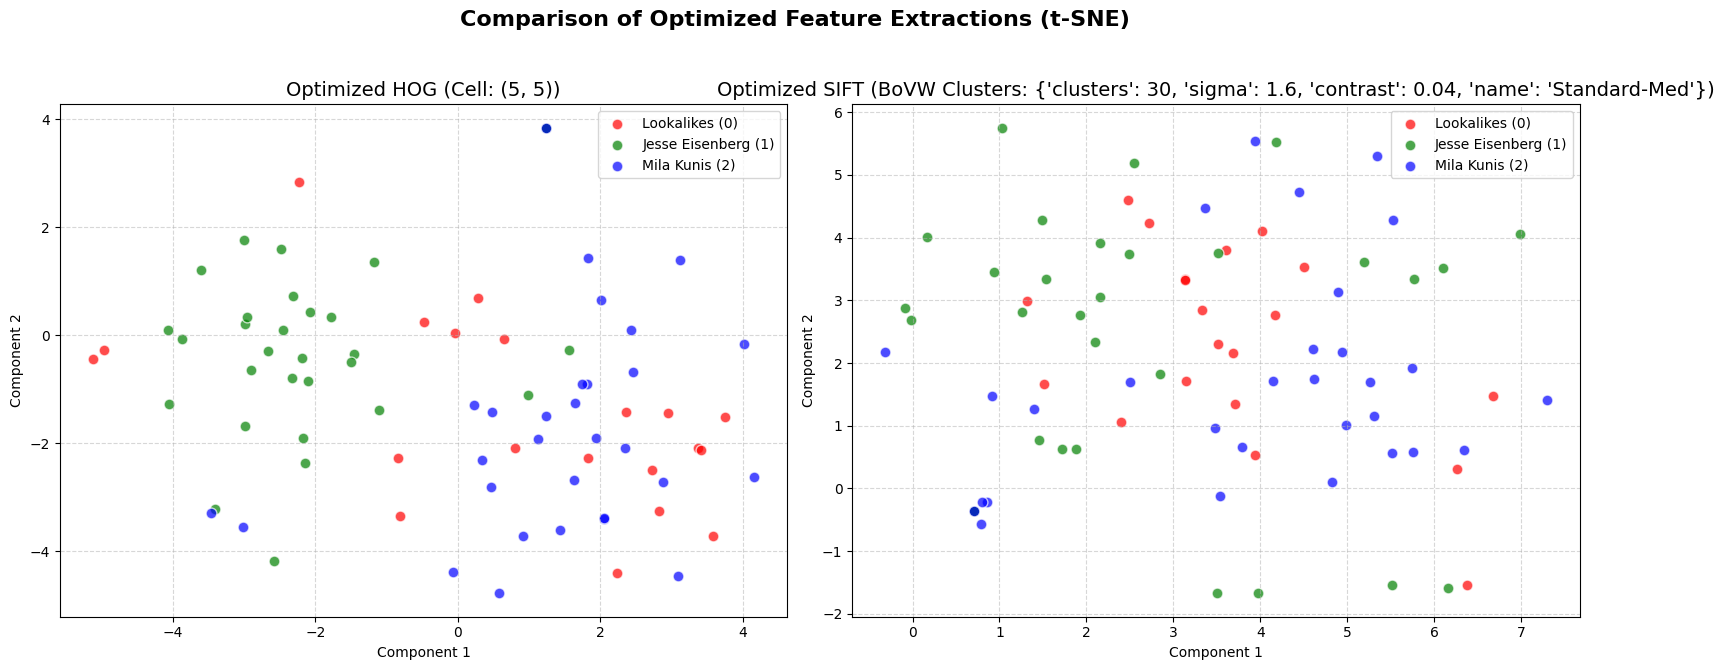

In [72]:
# ==========================================
# CELL 5: SIDE-BY-SIDE t-SNE VISUALIZATION
# ==========================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Running t-SNE on optimized HOG features...")
tsne_hog = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
hog_2d = tsne_hog.fit_transform(hog_train_scaled)

print("Running t-SNE on optimized SIFT features...")
tsne_sift = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
sift_2d = tsne_sift.fit_transform(sift_train_scaled)

# Set up the plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Comparison of Optimized Feature Extractions (t-SNE)', fontsize=16, fontweight='bold')

colors = ['red', 'green', 'blue']
labels = ['Lookalikes (0)', 'Jesse Eisenberg (1)', 'Mila Kunis (2)']

# --- Plot 1: HOG ---
for class_idx in range(3):
    idx = train_y == class_idx
    axes[0].scatter(
        hog_2d[idx, 0], hog_2d[idx, 1], 
        c=colors[class_idx], label=labels[class_idx], 
        alpha=0.7, edgecolors='w', s=60
    )
axes[0].set_title(f"Optimized HOG (Cell: {best_hog_config['cell']})", fontsize=14)
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: SIFT ---
for class_idx in range(3):
    idx = train_y == class_idx
    axes[1].scatter(
        sift_2d[idx, 0], sift_2d[idx, 1], 
        c=colors[class_idx], label=labels[class_idx], 
        alpha=0.7, edgecolors='w', s=60
    )
axes[1].set_title(f"Optimized SIFT (BoVW Clusters: {best_sift_config})", fontsize=14)
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout so title fits
plt.show()

### 1.1.2. Discussion
...

## 1.2. Baseline 2: PCA feature extractor
...

In [82]:
# ==========================================
# PCA FEATURE EXTRACTOR
# ==========================================
from sklearn.decomposition import PCA
import numpy as np
import cv2

class EigenfaceExtractor():
    """Learns features directly from image data using Principal Component Analysis."""
    
    def __init__(self, max_components=100):
        self.max_components = max_components
        self.is_fit = False
        self.pca = None # We will initialize this dynamically in fit_transform
        
    def _preprocess(self, images):
        """Converts images to grayscale and flattens them to 1D arrays."""
        processed = []
        for img in images:
            # Handle both RGB and already-grayscale images
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
            # Flatten 100x100 into a 10000-length vector
            processed.append(gray.flatten())
        return np.array(processed)
        
    def fit_transform(self, images):
        X = self._preprocess(images)
        
        # --- THE FIX ---
        # PCA cannot have more components than the number of samples (images).
        # We dynamically set n_components to be mathematically safe.
        n_samples = X.shape[0]
        actual_components = min(self.max_components, n_samples)
        
        print(f"Dataset has {n_samples} images.")
        print(f"Flattening images and learning the top {actual_components} Eigenfaces...")
        
        # Initialize PCA with the safe number of components
        self.pca = PCA(n_components=actual_components, whiten=True, random_state=42)
        
        features = self.pca.fit_transform(X)
        self.is_fit = True
        return features
        
    def transform(self, images):
        if not self.is_fit:
            raise ValueError("You must call fit_transform on train_X first!")
        X = self._preprocess(images)
        return self.pca.transform(X)

# Instantiate and extract features
pca_extractor = EigenfaceExtractor(max_components=100)
pca_train_features = pca_extractor.fit_transform(train_X)
pca_test_features = pca_extractor.transform(test_X)

print(f"Original flattened size: 10000 pixels")
print(f"New PCA Feature size: {pca_train_features.shape[1]} components")

Dataset has 80 images.
Flattening images and learning the top 80 Eigenfaces...
Original flattened size: 10000 pixels
New PCA Feature size: 80 components


In [83]:
# ==========================================
# OPTIMIZE & EVALUATE PCA
# ==========================================
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split

print("--- Starting PCA Performance Evaluation ---")

# Split raw images for validation
X_t_img, X_v_img, y_t, y_v = train_test_split(
    train_X, train_y, test_size=0.2, random_state=42, stratify=train_y
)

# Test keeping different numbers of Eigenfaces
pca_configs = [10, 20, 30, 40, 60, 80] 
best_pca_score = 0
best_pca_config = None
best_pca_clf = None
best_pca_val_feat = None

for n_comp in pca_configs:
    # 1. Initialize and Extract
    extractor = EigenfaceExtractor(max_components=n_comp)
    train_feat = extractor.fit_transform(X_t_img)
    val_feat = extractor.transform(X_v_img)
    
    # 2. Train an SVM 
    # Note: We use an 'rbf' kernel here because PCA features are highly non-linear!
    clf = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    clf.fit(train_feat, y_t)
    
    # 3. Evaluate
    preds = clf.predict(val_feat)
    score = f1_score(y_v, preds, average='weighted')
    
    print(f"Tested PCA [Components: {train_feat.shape[1]:<2}] -> Val F1-Score: {score:.4f}")
    
    if score > best_pca_score:
        best_pca_score = score
        best_pca_config = train_feat.shape[1]
        best_pca_clf = clf
        best_pca_val_feat = val_feat

print("\n" + "="*40)
print(f"🏆 BEST PCA FOUND: {best_pca_config} Components (Score: {best_pca_score:.4f})")
print("="*40)

# Let's print the detailed report for the winning PCA model
print("\nDetailed Performance of Best PCA:")
target_names = ['Lookalikes (0)', 'Jesse (1)', 'Mila (2)']
print(classification_report(y_v, best_pca_clf.predict(best_pca_val_feat), target_names=target_names))

# Re-extract the BEST PCA on the full dataset
final_pca = EigenfaceExtractor(max_components=best_pca_config)
pca_train_full = final_pca.fit_transform(train_X)
pca_test_full = final_pca.transform(test_X)

# Save it alongside HOG and SIFT
np.savez_compressed(
    'group16_features.npz', 
    hog_train=hog_train_scaled, 
    hog_test=hog_test_scaled, 
    sift_train=sift_train_scaled, 
    sift_test=sift_test_scaled,
    pca_train=pca_train_full,    # <-- Added PCA!
    pca_test=pca_test_full,      # <-- Added PCA!
    train_y=train_y
)

--- Starting PCA Performance Evaluation ---
Dataset has 64 images.
Flattening images and learning the top 10 Eigenfaces...
Tested PCA [Components: 10] -> Val F1-Score: 0.5232
Dataset has 64 images.
Flattening images and learning the top 20 Eigenfaces...
Tested PCA [Components: 20] -> Val F1-Score: 0.5250
Dataset has 64 images.
Flattening images and learning the top 30 Eigenfaces...
Tested PCA [Components: 30] -> Val F1-Score: 0.4875
Dataset has 64 images.
Flattening images and learning the top 40 Eigenfaces...
Tested PCA [Components: 40] -> Val F1-Score: 0.3874
Dataset has 64 images.
Flattening images and learning the top 60 Eigenfaces...
Tested PCA [Components: 60] -> Val F1-Score: 0.4821
Dataset has 64 images.
Flattening images and learning the top 64 Eigenfaces...
Tested PCA [Components: 64] -> Val F1-Score: 0.2045

🏆 BEST PCA FOUND: 20 Components (Score: 0.5250)

Detailed Performance of Best PCA:
                precision    recall  f1-score   support

Lookalikes (0)       0.33    

### 1.2.1. Eigenface Plots
...

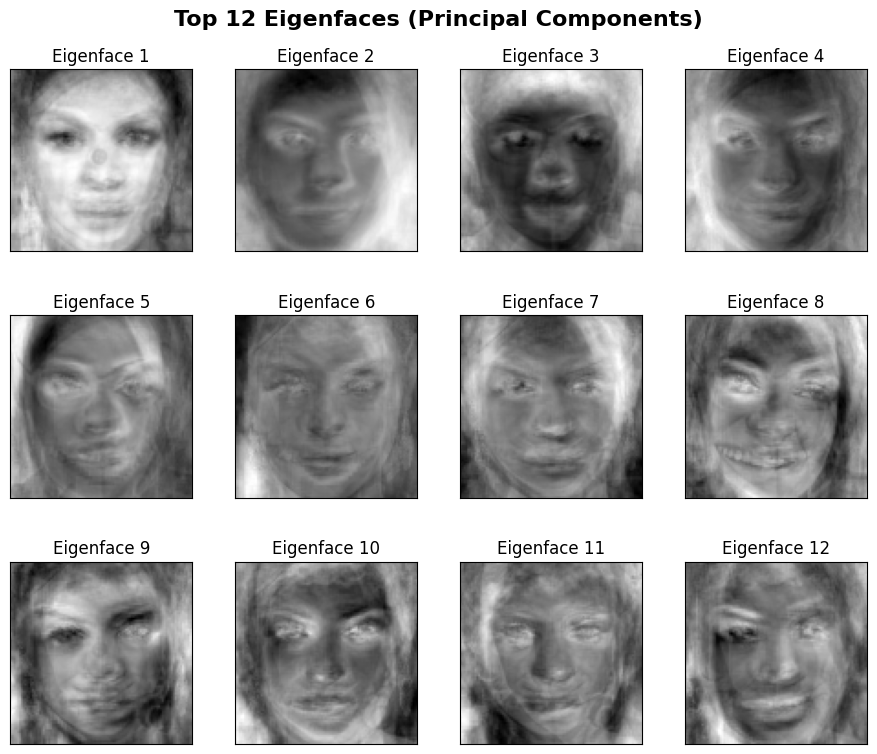

In [84]:
# ==========================================
# PLOT THE EIGENFACES
# ==========================================
import matplotlib.pyplot as plt

def plot_eigenfaces(pca_model, h=100, w=100, n_row=3, n_col=4):
    """Reshapes the principal components back into images and plots them."""
    
    # The components_ array holds the learned patterns
    eigenfaces = pca_model.components_.reshape((pca_model.n_components_, h, w))
    
    plt.figure(figsize=(2.2 * n_col, 2.5 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        # We plot them in grayscale, as color was discarded
        plt.imshow(eigenfaces[i], cmap=plt.cm.gray)
        plt.title(f"Eigenface {i+1}", size=12)
        plt.xticks(())
        plt.yticks(())
        
    plt.suptitle("Top 12 Eigenfaces (Principal Components)", fontsize=16, fontweight='bold')
    plt.show()

# Call the function using the PCA model hidden inside our extractor class
plot_eigenfaces(pca_extractor.pca)

### 1.2.2. Feature Space Plots
...

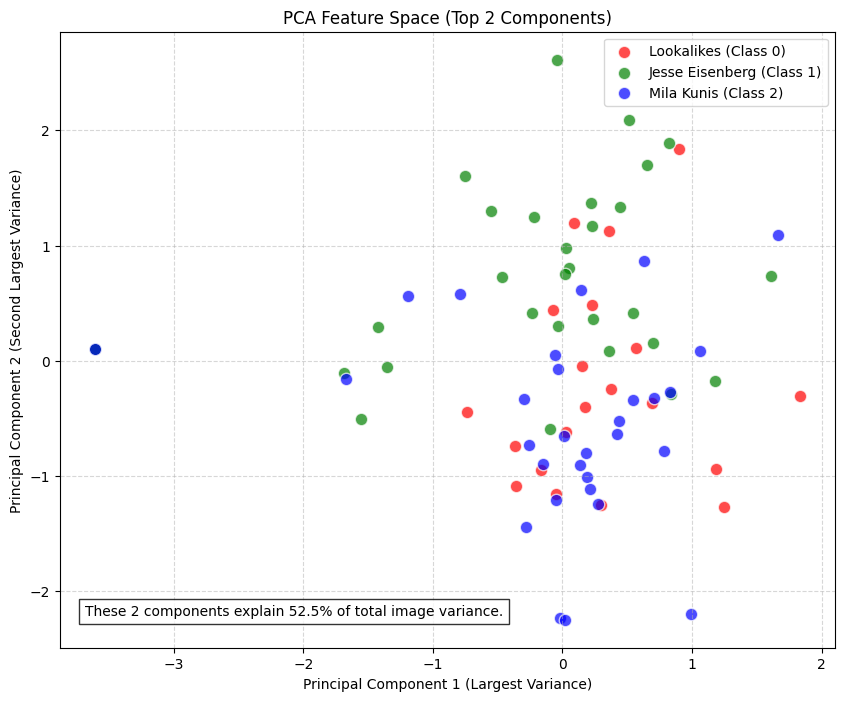

In [85]:
# ==========================================
# PCA FEATURE SPACE SCATTER PLOT
# ==========================================

plt.figure(figsize=(10, 8))

colors = ['red', 'green', 'blue']
labels = ['Lookalikes (Class 0)', 'Jesse Eisenberg (Class 1)', 'Mila Kunis (Class 2)']

# We plot the FIRST component (index 0) vs the SECOND component (index 1)
for class_idx in range(3):
    idx = train_y == class_idx
    plt.scatter(
        pca_train_features[idx, 0],  # PC1 (X-axis)
        pca_train_features[idx, 1],  # PC2 (Y-axis)
        c=colors[class_idx], 
        label=labels[class_idx], 
        alpha=0.7, edgecolors='w', s=80
    )

plt.title('PCA Feature Space (Top 2 Components)')
plt.xlabel('Principal Component 1 (Largest Variance)')
plt.ylabel('Principal Component 2 (Second Largest Variance)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Calculate how much "information" these two axes actually hold
explained_var = pca_extractor.pca.explained_variance_ratio_
total_var_2d = (explained_var[0] + explained_var[1]) * 100
plt.figtext(0.15, 0.15, f"These 2 components explain {total_var_2d:.1f}% of total image variance.", 
            fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

### 1.2.3. Discussion
...

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [46]:
from sklearn.metrics import accuracy_score


# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [79]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

In [86]:
# ==========================================
# BASELINE 1: MY FAVORITE CLASSIFIER
# ==========================================
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score
import numpy as np

class FavoriteClassificationModel:
    """
    An optimized Support Vector Machine (SVM) classifier.
    Automatically searches for the best C and gamma hyperparameters using cross-validation.
    """
    def __init__(self):
        self.best_model = None
        self.best_params = None
        self.best_score = 0
        
    def fit(self, X, y):
        print("Starting Grid Search for SVM Hyperparameters...")
        
        # Define the parameter grid for an RBF Kernel
        # class_weight='balanced' is CRUCIAL here because you have many Lookalikes (Class 0) 
        # but fewer images of Jesse and Mila.
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
            'class_weight': ['balanced'] 
        }
        
        # Initialize GridSearch with 5-fold cross-validation
        # n_jobs=-1 tells Kaggle to use all available CPU cores to run this 4x faster!
        grid_search = GridSearchCV(
            SVC(kernel='rbf', random_state=42), 
            param_grid, 
            cv=5, 
            scoring='f1_weighted', 
            n_jobs=-1, 
            verbose=1
        )
        
        # Fit the model to find the best parameters
        grid_search.fit(X, y)
        
        # Save the winning model
        self.best_model = grid_search.best_estimator_
        self.best_params = grid_search.best_params_
        self.best_score = grid_search.best_score_
        
        print("\n✅ Training Complete!")
        print(f"Best Parameters: {self.best_params}")
        print(f"Best Cross-Validation F1-Score: {self.best_score:.4f}")
        
        return self

    def __call__(self, X):
        """Predicts labels for the input data."""
        if self.best_model is None:
            raise ValueError("Model has not been trained. Call .fit() first.")
        return self.best_model.predict(X)

In [89]:
# ==========================================
# TRAIN & EVALUATE THE FAVORITE CLASSIFIER
# ==========================================
from sklearn.model_selection import train_test_split

print("1. Loading optimized features from Part 1...")
data = np.load('group16_features.npz')

# Choose your best feature set here! (hog_train, sift_train, or pca_train)
X_train_full = data['hog_train']  
y_train_full = data['train_y']

# Split a quick validation set to see the final Confusion Matrix/Report
X_t, X_v, y_t, y_v = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# 2. Instantiate and fit the model
favorite_model = FavoriteClassificationModel()
favorite_model.fit(X_t, y_t)

# 3. Final Validation Evaluation
print("\n--- Final Model Performance on Validation Set ---")
val_predictions = favorite_model(X_v)

target_names = ['Lookalikes (0)', 'Jesse (1)', 'Mila (2)']
print(classification_report(y_v, val_predictions, target_names=target_names))

# 4. Retrain on 100% of the data for the final Kaggle Submission
print("\nRetraining the absolute best model on 100% of training data for Kaggle submission...")
final_kaggle_model = FavoriteClassificationModel()
final_kaggle_model.fit(X_train_full, y_train_full)

1. Loading optimized features from Part 1...
Starting Grid Search for SVM Hyperparameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Training Complete!
Best Parameters: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale'}
Best Cross-Validation F1-Score: 0.6710

--- Final Model Performance on Validation Set ---
                precision    recall  f1-score   support

Lookalikes (0)       0.00      0.00      0.00         4
     Jesse (1)       0.67      0.67      0.67         6
      Mila (2)       0.50      0.83      0.62         6

      accuracy                           0.56        16
     macro avg       0.39      0.50      0.43        16
  weighted avg       0.44      0.56      0.48        16


Retraining the absolute best model on 100% of training data for Kaggle submission...
Starting Grid Search for SVM Hyperparameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Training Complete!
Best Parameters: {'C': 10, 'class_weight': 'bal

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [ ]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [ ]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

In [ ]:
# predict the labels for the test set 
test_y_star = model(test_X)

# 5. Publishing best results

In [ ]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission

In [ ]:
submission.to_csv('submission.csv')

# 6. Discussion
...

In summary we contributed the following: 
* 
